In [ ]:
import pandas as pd
print("pandas version:", pd.__version__)


pandas version: 2.2.2


In [ ]:
data = {
    'vendedor': ['Ana', 'Carlos', 'Ana', 'Luis', 'Carlos', 'María'],
    'region': ['Norte', 'Sur', 'Norte', 'Norte', 'Sur', 'Sur'],
    'monto': [1500, 200, 350, 1800, 1600, 1700]
}

df = pd.DataFrame(data)
print(df)

  vendedor region  monto
0      Ana  Norte   1500
1   Carlos    Sur    200
2      Ana  Norte    350
3     Luis  Norte   1800
4   Carlos    Sur   1600
5    María    Sur   1700


In [ ]:
df['vendedor']
df[df['region'] == 'Norte']

,vendedor,region,monto
0,Ana,Norte,1500
2,Ana,Norte,350
3,Luis,Norte,1800


In [ ]:
df.groupby('vendedor') ['monto'].sum()

,monto
vendedor,
Ana,1850
Carlos,1800
Luis,1800
María,1700


In [ ]:
df[df['region'] == 'Norte'].groupby('vendedor')['monto'].sum().sort_values(ascending=False)

,monto
vendedor,
Ana,1850
Luis,1800


In [ ]:
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_items.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
df_items.shape
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
df_items[['price']].mean()

,0
price,120.653739


In [ ]:
df_items[['order_id']].nunique()

,0
order_id,98666


In [ ]:
df_items.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(5)

,price
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
53243585a1d6dc2643021fd1853d8905,222776.05
4a3ca9315b744ce9f8e9374361493884,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,194042.03
7c67e1448b00f6e969d365cea6b010ab,187923.89


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pedidos = pd.read_csv('olist_order_items_dataset.csv')
print("Listo!")

Listo!


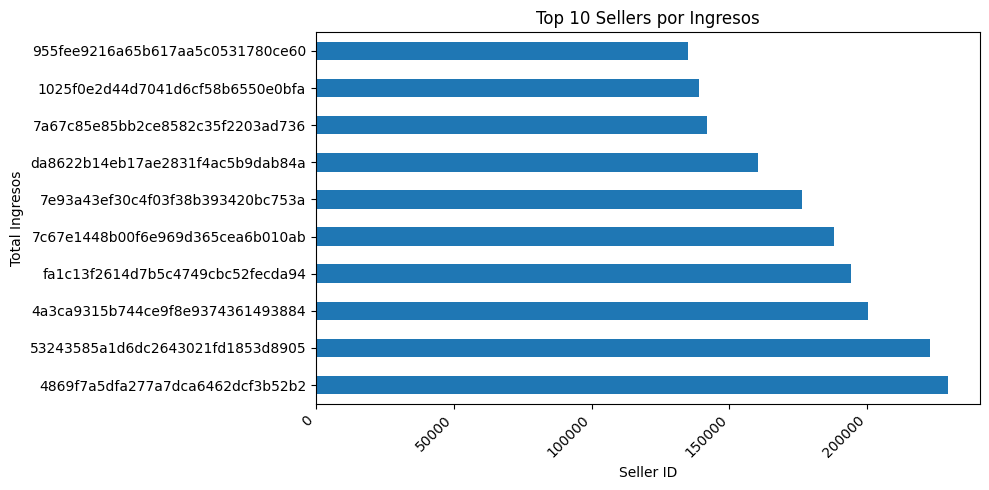

In [4]:
# Top 10 sellers por precio total
top_sellers = pedidos.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_sellers.plot(kind='barh')
plt.title('Top 10 Sellers por Ingresos')
plt.xlabel('Seller ID')
plt.ylabel('Total Ingresos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
ordenes = pd.read_csv('olist_orders_dataset.csv')
ordenes['order_purchase_timestamp'] = pd.to_datetime(ordenes['order_purchase_timestamp'])
ordenes['mes'] = ordenes['order_purchase_timestamp'].dt.to_period('M').astype(str)
ordenes.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,mes
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02


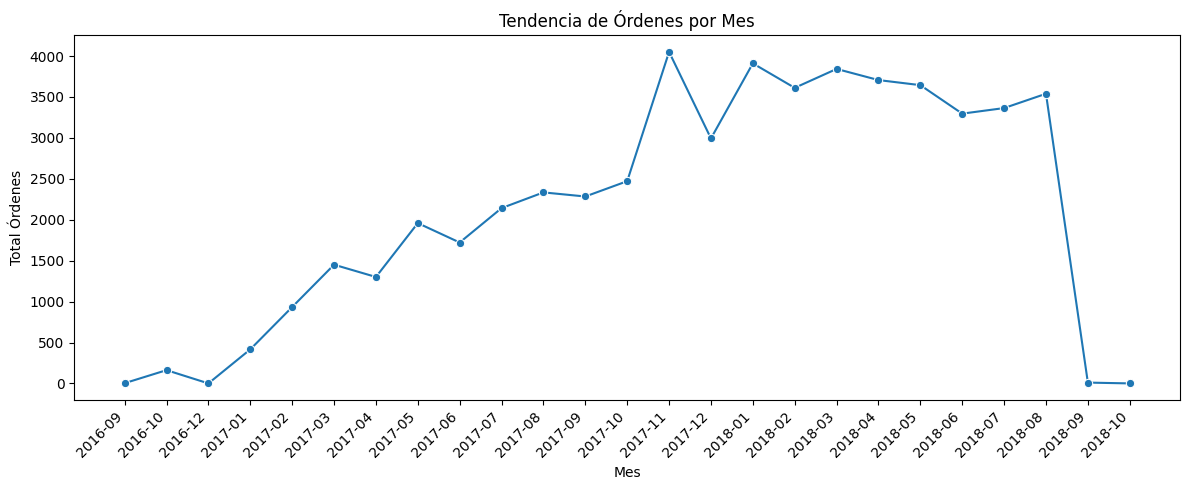

In [7]:
ordenes_por_mes = ordenes.groupby('mes')['order_id'].count().reset_index()
ordenes_por_mes.columns = ['mes', 'total_ordenes']

plt.figure(figsize=(12, 5))
sns.lineplot(data=ordenes_por_mes, x='mes', y='total_ordenes', marker='o')
plt.title('Tendencia de Órdenes por Mes')
plt.xlabel('Mes')
plt.ylabel('Total Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
df_completo = pedidos.merge(ordenes, on='order_id', how='inner')
df_completo.shape

(60150, 15)

In [9]:
df_completo['order_purchase_timestamp'] = pd.to_datetime(df_completo['order_purchase_timestamp'])
df_completo['mes'] = df_completo['order_purchase_timestamp'].dt.to_period('M').astype(str)

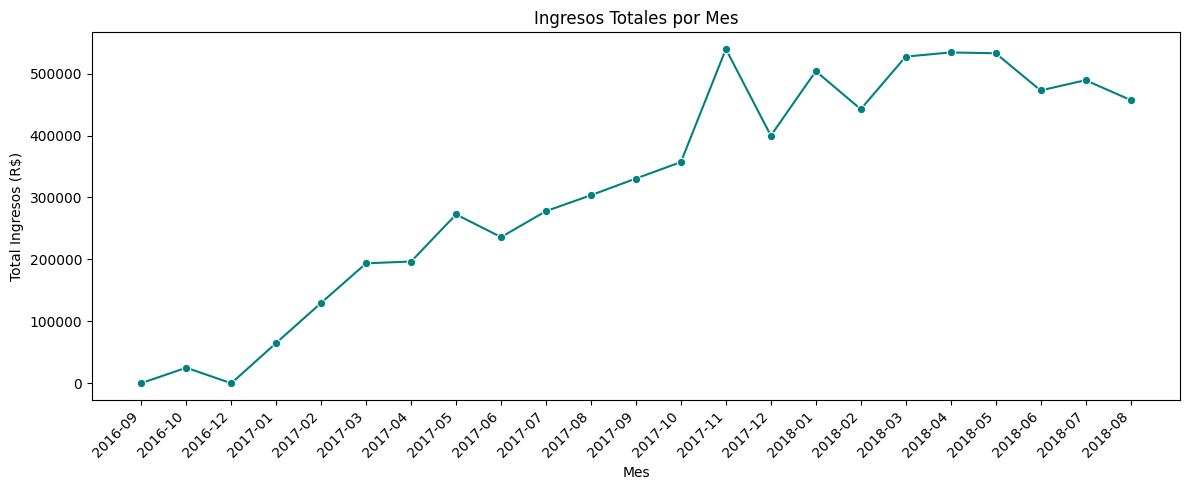

In [10]:
ingresos_mes = df_completo.groupby('mes')['price'].sum().reset_index()
ingresos_mes.columns = ['mes', 'total_ingresos']

plt.figure(figsize=(12, 5))
sns.lineplot(data=ingresos_mes, x='mes', y='total_ingresos', marker='o', color='teal')
plt.title('Ingresos Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Total Ingresos (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

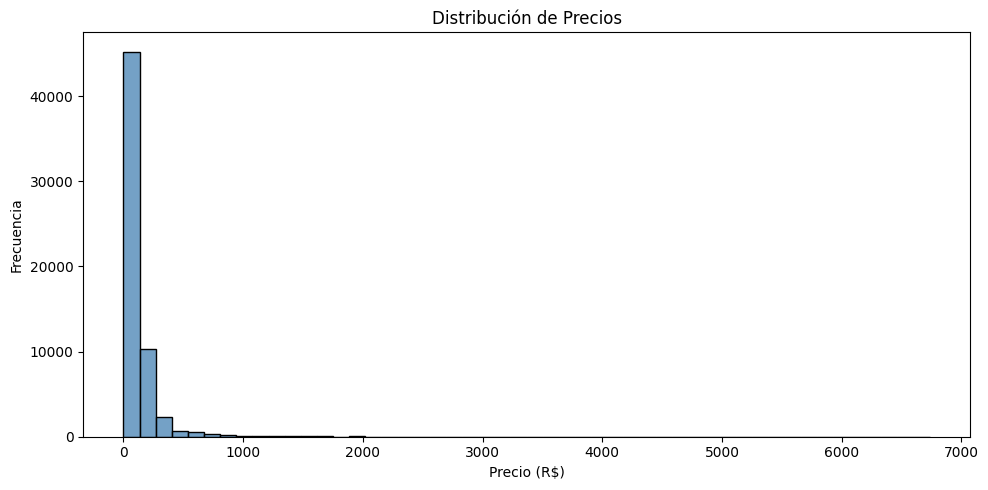

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df_completo['price'], bins=50, color='steelblue')
plt.title('Distribución de Precios')
plt.xlabel('Precio (R$)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [13]:
print("Promedio:", round(df_completo['price'].mean(), 2))
print("Mediana:", round(df_completo['price'].median(), 2))

Promedio: 121.17
Mediana: 74.9
